In [1]:
import time
import random
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import erf

import sys
sys.path.insert(0, '/home/ferjao_k/sw/aare/build')
from aare import fit_scurve, fit_scurve2, fit_scurve_minuit_grad, fit_scurve2_minuit_grad
from aare import RisingScurve, FallingScurve, fit # object based API

## Model curves

In [2]:
def scurve(x, p): # rising Scurve
    p0, p1, p2, p3, p4, p5 = p
    return (p0 + p1*x) + 0.5 *(1 + erf((x-p2) / (np.sqrt(2)*p3))) * (p4 + p5*(x-p2))

def scurve2(x, p): #falling Scurve
    p0, p1, p2, p3, p4, p5 = p
    return (p0 + p1*x) + 0.5 *(1 - erf((x-p2) / (np.sqrt(2)*p3))) * (p4 + p5*(x-p2))

## Generate data (1D)

In [3]:
x = np.linspace(0,120, 121)

rng = np.random.default_rng(42)
0
p_true_rising = np.array([100.0, 0.25, 60.0, 6.0, 120.0,  1.0])
p_true_falling = np.array([100.0, 0.25, 60.0, 6.0, 120.0, -1.0])

y_true_rising = scurve(x, p_true_rising)
y_true_falling = scurve2(x, p_true_falling)

noise_sigma = 4

y_rising = y_true_rising + rng.normal(0, noise_sigma, size=x.shape)
# y_err_r = np.full_like(x, noise_sigma)

y_falling = y_true_falling + rng.normal(0, noise_sigma, size=x.shape)
# y_err_f = np.full_like(x, noise_sigma)

## Plot synthetic data

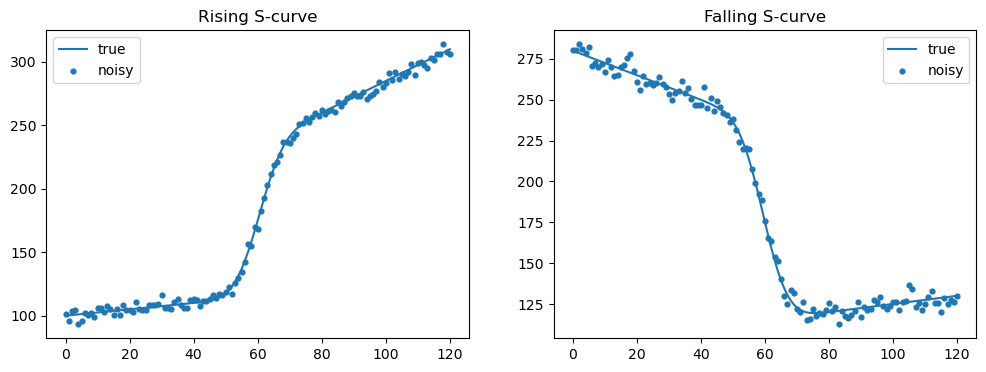

In [4]:
fig, ax = plt.subplots(1, 2, figsize=(12,4), sharex=True)

ax[0].plot(x, y_true_rising, label="true")
ax[0].scatter(x, y_rising, s=12, label="noisy")
ax[0].set_title("Rising S-curve")
ax[0].legend()

ax[1].plot(x, y_true_falling, label="true")
ax[1].scatter(x, y_falling, s=12, label="noisy")
ax[1].set_title("Falling S-curve")
ax[1].legend()

plt.show()

## Fit the Rising S-curve

In [5]:
res_r_lmfit = fit_scurve(x, y_rising)
res_r_minuit_grad = fit_scurve_minuit_grad(x, y_rising)

model_r = RisingScurve()
model_r.FixParameter(0, 100)  # Fixed p0 = 100 (optimizer does not touch the value)
model_r.SetStartValue(4, 100) # Start value p4 = 100 
print(f"max_calls : {model_r.max_calls}")
print(f"tolerance : {model_r.tolerance}")
print(f"compute_erros: {model_r.compute_errors}")
res_r_munuit_obj = fit(model_r, x, y_rising)

print("True rising params:         ", p_true_rising)
print("lmfit rising result:        ", res_r_lmfit)
print("minuit_grad (fct call) rising result:  ", res_r_minuit_grad[:-1])
print("minuit_grad (obj api ) rising result:  ", res_r_munuit_obj[:-1])

max_calls : 100
tolerance : 0.5
compute_erros: False
True rising params:          [100.     0.25  60.     6.   120.     1.  ]
lmfit rising result:         [ 99.46783104   0.28701685  60.07840507   5.71546071 117.25793891
   0.96723356]
minuit_grad (fct call) rising result:   [ 99.46795493   0.28701227  60.07843667   5.7154553  117.2583506
   0.96723277]
minuit_grad (obj api ) rising result:   [100.           0.27059621  60.04702975   5.74813364 117.726364
   0.98264073]


## Fit the Falling S-curve

In [6]:
res_f_lmfit = fit_scurve2(x, y_falling)
res_f_minuit_grad = fit_scurve2_minuit_grad(x, y_falling)

model_f = FallingScurve()
model_f.SetStartValue(2, 20) # set start p2 = 20
model_f.SetStartValue(4, 90) # set start p4 = 90
model_f.SetParLimits(4, 80, 130)
model_f.max_calls = 150 # this is limits the number of calls done by the minimizer (increasing the `max_calls` may help if the fit fails) 
res_f_munuit_obj = fit(model_f, x, y_falling)

print("True falling params:  ", p_true_falling)
print("lmfit falling result:  ", res_f_lmfit)
print("minuit_grad (fct call) falling result:  ", res_f_minuit_grad[:-1])
print("minuit_grad (obj api ) falling result:  ", res_f_munuit_obj[:-1])

True falling params:   [100.     0.25  60.     6.   120.    -1.  ]
lmfit falling result:   [101.73447899   0.2257864   60.25197087   6.09291484 118.47673528
  -0.99867704]
minuit_grad (fct call) falling result:   [101.73561859   0.22577771  60.25195788   6.09264042 118.47565078
  -0.99868055]
minuit_grad (obj api ) falling result:   [101.73440291   0.22577842  60.25166721   6.09324463 118.47945706
  -0.99860305]


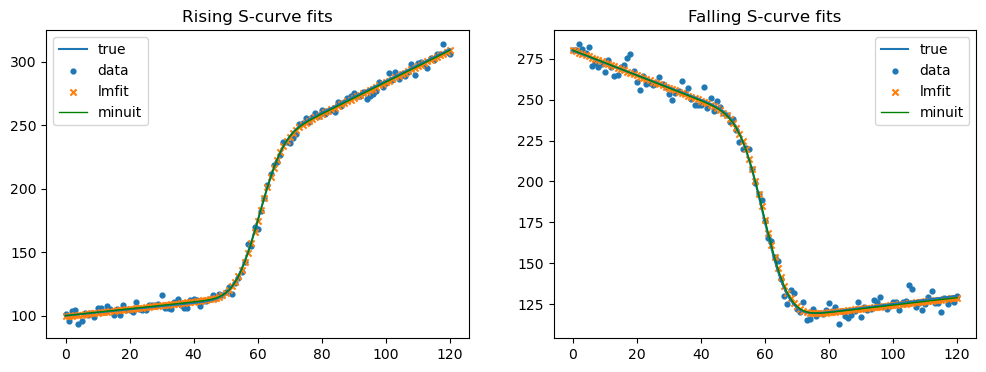

In [7]:
fig, ax = plt.subplots(1, 2, figsize=(12,4))

# rising
ax[0].plot(x, y_true_rising, label="true")
ax[0].scatter(x, y_rising, s=12, label="data")
ax[0].scatter(x, scurve(x, res_r_lmfit[:6]), s=20, marker="x", label="lmfit")
# ax[0].plot(x, scurve(x, res_r_minuit_grad[:6]), linewidth=1, color="green", label="minuit")
ax[0].plot(x, scurve(x, res_r_munuit_obj[:6]), linewidth=1, color="green", label="minuit")
ax[0].set_title("Rising S-curve fits")
ax[0].legend()

# falling
ax[1].plot(x, y_true_falling, label="true")
ax[1].scatter(x, y_falling, s=12, label="data")
ax[1].scatter(x, scurve2(x, res_f_lmfit[:6]), s=20, marker="x", label="lmfit")
# ax[1].plot(x, scurve2(x, res_f_minuit_grad[:6]), linewidth=1, color="green", label="minuit")
ax[1].plot(x, scurve2(x, res_f_munuit_obj[:6]), linewidth=1, color="green", label="minuit")
ax[1].set_title("Falling S-curve fits")
ax[1].legend()

plt.show()

## Quick error check

In [8]:
print("Rising abs error lmfit : ", np.abs(res_r_lmfit[:6] - p_true_rising))
# print("Rising abs error minuit_grad: ", np.abs(res_r_minuit_grad[:6] - p_true_rising))
print("Rising abs error minuit_grad: ", np.abs(res_r_munuit_obj[:6] - p_true_rising))
print("\n")
print("Falling abs error lmfit : ", np.abs(res_f_lmfit[:6] - p_true_falling))
# print("Falling abs error minuit_grad: ", np.abs(res_f_minuit_grad[:6] - p_true_falling))
print("Falling abs error minuit_grad: ", np.abs(res_f_munuit_obj[:6] - p_true_falling))

Rising abs error lmfit :  [0.53216896 0.03701685 0.07840507 0.28453929 2.74206109 0.03276644]
Rising abs error minuit_grad:  [0.         0.02059621 0.04702975 0.25186636 2.273636   0.01735927]


Falling abs error lmfit :  [1.73447899e+00 2.42135973e-02 2.51970871e-01 9.29148384e-02
 1.52326472e+00 1.32296033e-03]
Falling abs error minuit_grad:  [1.73440291e+00 2.42215788e-02 2.51667214e-01 9.32446279e-02
 1.52054294e+00 1.39695020e-03]


## Benchmark

In [9]:
def bench(fn, n_repeats=200):
    # warmup
    for _ in range(3):
        fn()

    t0 = time.perf_counter()
    for _ in range(n_repeats):
        res = fn()
    t1 = time.perf_counter()
    return res, (t1 - t0) / n_repeats

model_rising  = RisingScurve()
model_falling = FallingScurve()

res_r_lmfit,  t_r_lmfit       = bench(lambda: fit_scurve(x, y_rising))
res_r_minuit, t_r_minuit_grad = bench(lambda: fit_scurve_minuit_grad(x, y_rising))
res_r_new,    t_r_new         = bench(lambda: fit(model_rising, x, y_rising))

res_f_lmfit,  t_f_lmfit       = bench(lambda: fit_scurve2(x, y_falling))
res_f_minuit, t_f_minuit_grad = bench(lambda: fit_scurve2_minuit_grad(x, y_falling))
res_f_new,    t_f_new         = bench(lambda: fit(model_falling, x, y_falling))

print(f"Rising  lmfit       : {1e3*t_r_lmfit:.3f} ms")
print(f"Rising  minuit_grad : {1e3*t_r_minuit_grad:.3f} ms")
print(f"Rising  fit(model)  : {1e3*t_r_new:.3f} ms")
print()
print(f"Falling lmfit       : {1e3*t_f_lmfit:.3f} ms")
print(f"Falling minuit_grad : {1e3*t_f_minuit_grad:.3f} ms")
print(f"Falling fit(model)  : {1e3*t_f_new:.3f} ms")

Rising  lmfit       : 0.466 ms
Rising  minuit_grad : 0.330 ms
Rising  fit(model)  : 0.309 ms

Falling lmfit       : 0.391 ms
Falling minuit_grad : 0.314 ms
Falling fit(model)  : 0.305 ms
